# Multiple Linear Regression


## import packages


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load Data From a CSV file

In [2]:
data = pd.read_csv('FuelConsumption.csv')
data

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [3]:
c_data = data[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
c_data

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
...,...,...,...,...
1062,3.0,6,11.8,271
1063,3.2,6,11.5,264
1064,3.0,6,11.8,271
1065,3.2,6,11.3,260


## Get some info about datas 

Text(0.5, 0, 'ENGINESIZE')

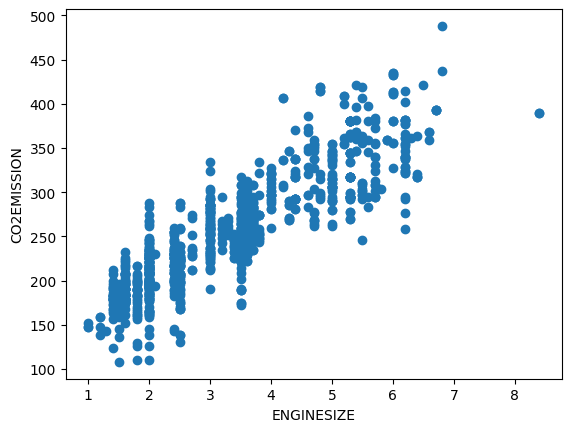

In [4]:
plt.scatter(c_data.ENGINESIZE, c_data.CO2EMISSIONS)
plt.ylabel('CO2EMISSION')
plt.xlabel('ENGINESIZE')

Text(0.5, 0, 'Cylinder')

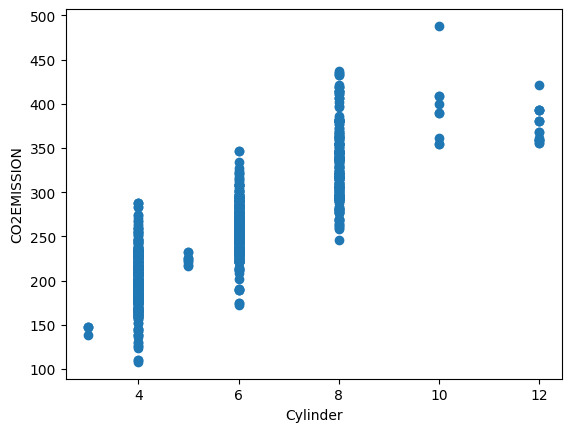

In [5]:
plt.scatter(c_data.CYLINDERS, c_data.CO2EMISSIONS)
plt.ylabel('CO2EMISSION')
plt.xlabel('Cylinder')

Text(0.5, 0, 'FUELCONSUMPTION_COMB')

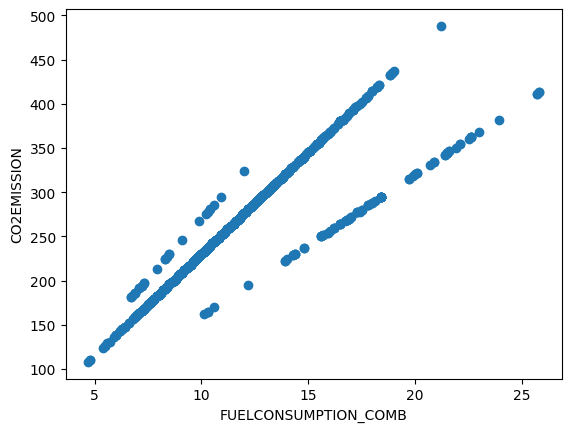

In [6]:
plt.scatter(c_data.FUELCONSUMPTION_COMB, c_data.CO2EMISSIONS)
plt.ylabel('CO2EMISSION')
plt.xlabel('FUELCONSUMPTION_COMB')

## Create Test and Train daatas

In [7]:
mask = np.random.rand(len(data)) < 0.8
train = c_data[mask]
test = c_data[~mask]
train, test

(      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
 0            2.0          4                   8.5           196
 2            1.5          4                   5.9           136
 3            3.5          6                  11.1           255
 4            3.5          6                  10.6           244
 5            3.5          6                  10.0           230
 ...          ...        ...                   ...           ...
 1060         3.0          6                  11.5           264
 1061         3.2          6                  11.2           258
 1063         3.2          6                  11.5           264
 1064         3.0          6                  11.8           271
 1065         3.2          6                  11.3           260
 
 [853 rows x 4 columns],
       ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
 1            2.4          4                   9.6           221
 19           2.0          4                   8.8           20

Text(0.5, 0, 'Engine Size')

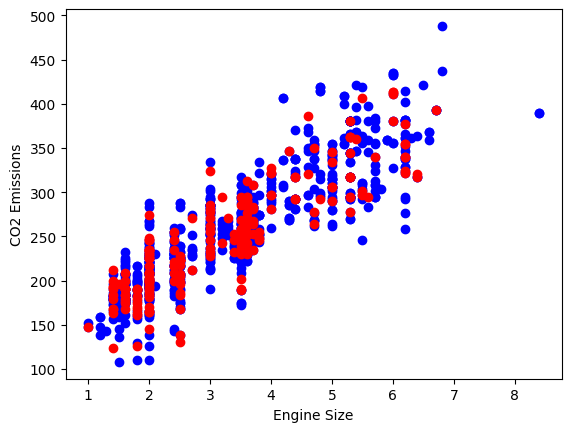

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
ax.scatter(test.ENGINESIZE, test.CO2EMISSIONS, color='red')
plt.ylabel('CO2 Emissions')
plt.xlabel('Engine Size')

Text(0.5, 0, 'Cylinder')

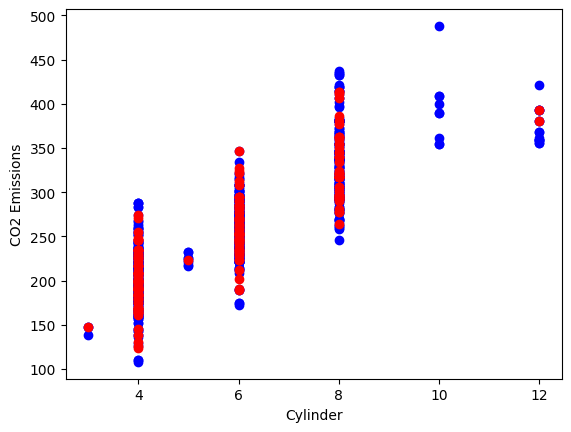

In [9]:
fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.scatter(train.CYLINDERS, train.CO2EMISSIONS, color='blue')
ax1.scatter(test.CYLINDERS, test.CO2EMISSIONS, color='red')
plt.ylabel('CO2 Emissions')
plt.xlabel('Cylinder')

## create MULTIPLE MODEL

In [10]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
reg.fit(train_x, train_y)
print(f'Coef: {reg.coef_}')
print(f'Intercept: {reg.intercept_}')

Coef: [[11.87723515  6.45401627  9.94352021]]
Intercept: [64.56227793]


## Prediction

In [11]:
from sklearn.metrics import r2_score

y_hat = reg.predict(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
x = np.asanyarray(test[['FUELCONSUMPTION_COMB']])
y = np.asanyarray(test[['CO2EMISSIONS']])
print('Residual sum of squares: %.4f' % np.mean((y_hat - y) ** 2))
print('R2: %.4f' % r2_score(y , y_hat) )

Residual sum of squares: 537.7443
R2: 0.8610


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


## SELF TEST

In [12]:
reg.predict([[2, 4, 8.5]])

array([[198.65273508]])